In [197]:
#importowanie bibliotek

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

***Preprocessing***

In [198]:
#ladowanie danych

breast_data = pd.read_csv("Breast_Cancer.csv")
breast_data

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive


In [199]:
#sprawdzenie specyfiki danych
#sprawdzenie czy istnieja jakies wartosci null, jesli nie to trzeba zamienic kolumny tekstowe na numeryczne
breast_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [200]:
#sprawdzenie wartosci w kolumnach tekstowych
text_columns = breast_data.select_dtypes(include=['object']).columns

for name in text_columns:
    print(f"----{name}----")
    print(breast_data[name].unique())

----Race----
['White' 'Black' 'Other']
----Marital Status----
['Married' 'Divorced' 'Single ' 'Widowed' 'Separated']
----T Stage ----
['T1' 'T2' 'T3' 'T4']
----N Stage----
['N1' 'N2' 'N3']
----6th Stage----
['IIA' 'IIIA' 'IIIC' 'IIB' 'IIIB']
----differentiate----
['Poorly differentiated' 'Moderately differentiated' 'Well differentiated'
 'Undifferentiated']
----Grade----
['3' '2' '1' ' anaplastic; Grade IV']
----A Stage----
['Regional' 'Distant']
----Estrogen Status----
['Positive' 'Negative']
----Progesterone Status----
['Positive' 'Negative']
----Status----
['Alive' 'Dead']


In [201]:
#zamiana na wartosci liczbowe
#kolejnosc ma znaczenie

hierarchie = {
    "T Stage ": ['T1', 'T2', 'T3', 'T4'],
    "N Stage": ['N1', 'N2', 'N3'],
    "6th Stage": ['IIA', 'IIB', 'IIIA', 'IIIB', 'IIIC'],
    "Grade": ['1', '2', '3', ' anaplastic; Grade IV'],
    "differentiate": ['Undifferentiated', 'Poorly differentiated', 'Moderately differentiated', 'Well differentiated'] 
}

for name, order in hierarchie.items():
    ordinal_enc = OrdinalEncoder(categories=[order])

    breast_data[name] = ordinal_enc.fit_transform(breast_data[[name]])

# kolejnosc nie ma znaczenia
# tworzy od razu nowe kolumny race_rasa
columns_onehot = ["Race", "Marital Status", "A Stage", "Estrogen Status", "Progesterone Status", "Status"]

for name in columns_onehot:
    onehot_enc = OneHotEncoder(sparse_output=False, drop='first')
    coded = onehot_enc.fit_transform(breast_data[[name]])
    new_col_names = onehot_enc.get_feature_names_out([name])

    df_temp = pd.DataFrame(coded, columns=new_col_names, index=breast_data.index)

    breast_data = pd.concat([breast_data, df_temp], axis=1)

    breast_data = breast_data.drop(columns=[name])

breast_data

,Age,T Stage,N Stage,6th Stage,differentiate,Grade,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed,A Stage_Regional,Estrogen Status_Positive,Progesterone Status_Positive,Status_Dead
0,68,0.0,0.0,0.0,1.0,2.0,4,24,1,60,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,50,1.0,1.0,2.0,2.0,1.0,35,14,5,62,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,58,2.0,2.0,4.0,2.0,1.0,63,14,7,75,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,58,0.0,0.0,0.0,1.0,2.0,18,2,1,84,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,47,1.0,0.0,1.0,1.0,2.0,41,3,1,50,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,0.0,0.0,0.0,2.0,1.0,9,1,1,49,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4020,56,1.0,1.0,2.0,2.0,1.0,46,14,8,69,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4021,68,1.0,0.0,1.0,2.0,1.0,22,11,3,69,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4022,58,1.0,0.0,1.0,2.0,1.0,44,11,1,72,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [202]:
breast_data.describe()

,Age,T Stage,N Stage,6th Stage,differentiate,Grade,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed,A Stage_Regional,Estrogen Status_Positive,Progesterone Status_Positive,Status_Dead
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,0.784791,0.438370,1.321819,1.849404,1.150596,30.473658,14.357107,4.158052,71.297962,0.079523,0.848161,0.656809,0.011183,0.152833,0.058400,0.977137,0.933151,0.826541,0.153082
std,8.963134,0.765531,0.693479,1.266624,0.638234,0.638234,21.119696,8.099675,5.109331,22.921430,0.270587,0.358909,0.474834,0.105169,0.359871,0.234527,0.149485,0.249791,0.378691,0.360111
min,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,0.000000,1.000000,1.000000,16.000000,9.000000,1.000000,56.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,1.000000,2.000000,1.000000,25.000000,14.000000,2.000000,73.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,61.000000,1.000000,1.000000,2.000000,2.000000,2.000000,38.000000,19.000000,5.000000,90.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
max,69.000000,3.000000,2.000000,4.000000,3.000000,3.000000,140.000000,61.000000,46.000000,107.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Dane statystyczne w tabeli mowia o paru ciekawych zjawiskach wsrod osob badanych. 
Przede wszystkim srednia wieku osob chorych/podejrzanych wynosi 53 lata z odchyleniem na poziomie blisko 9 lat.
Nawet w przypadku gdy pacjent jest obarczony wadliwym genem to profilaktyka rozpoczyna sie po 25 roku zycia, nie wyklucza to jednak ryzyka cywilizacyjnego.
T Stage na poziomie srednio nieprzekraczajacym nawet 1.0 oznacza ze wiekszosc pacjentow podjetych analizie choruje na nowotwor zlosliwy wykryty jednak w bardzo wczesnym stadium. Daje to o wiele wieksze szanse na przezycie i zmienia sposob podejscia do leczenia.
Samo zakwalifikowanie pacjenta do ktoregokolwiek ze stadiow T Stage oznacza ze ma sie juz doczynienia z nowotworem zlosliwym. 
Przezywalnosc wyrazona w miesiacach to srednio az 71, co w podzielone przez 12 daje blisko 6 lat.

<Axes: title={'center': 'Parametry do analizy raka piersi'}>

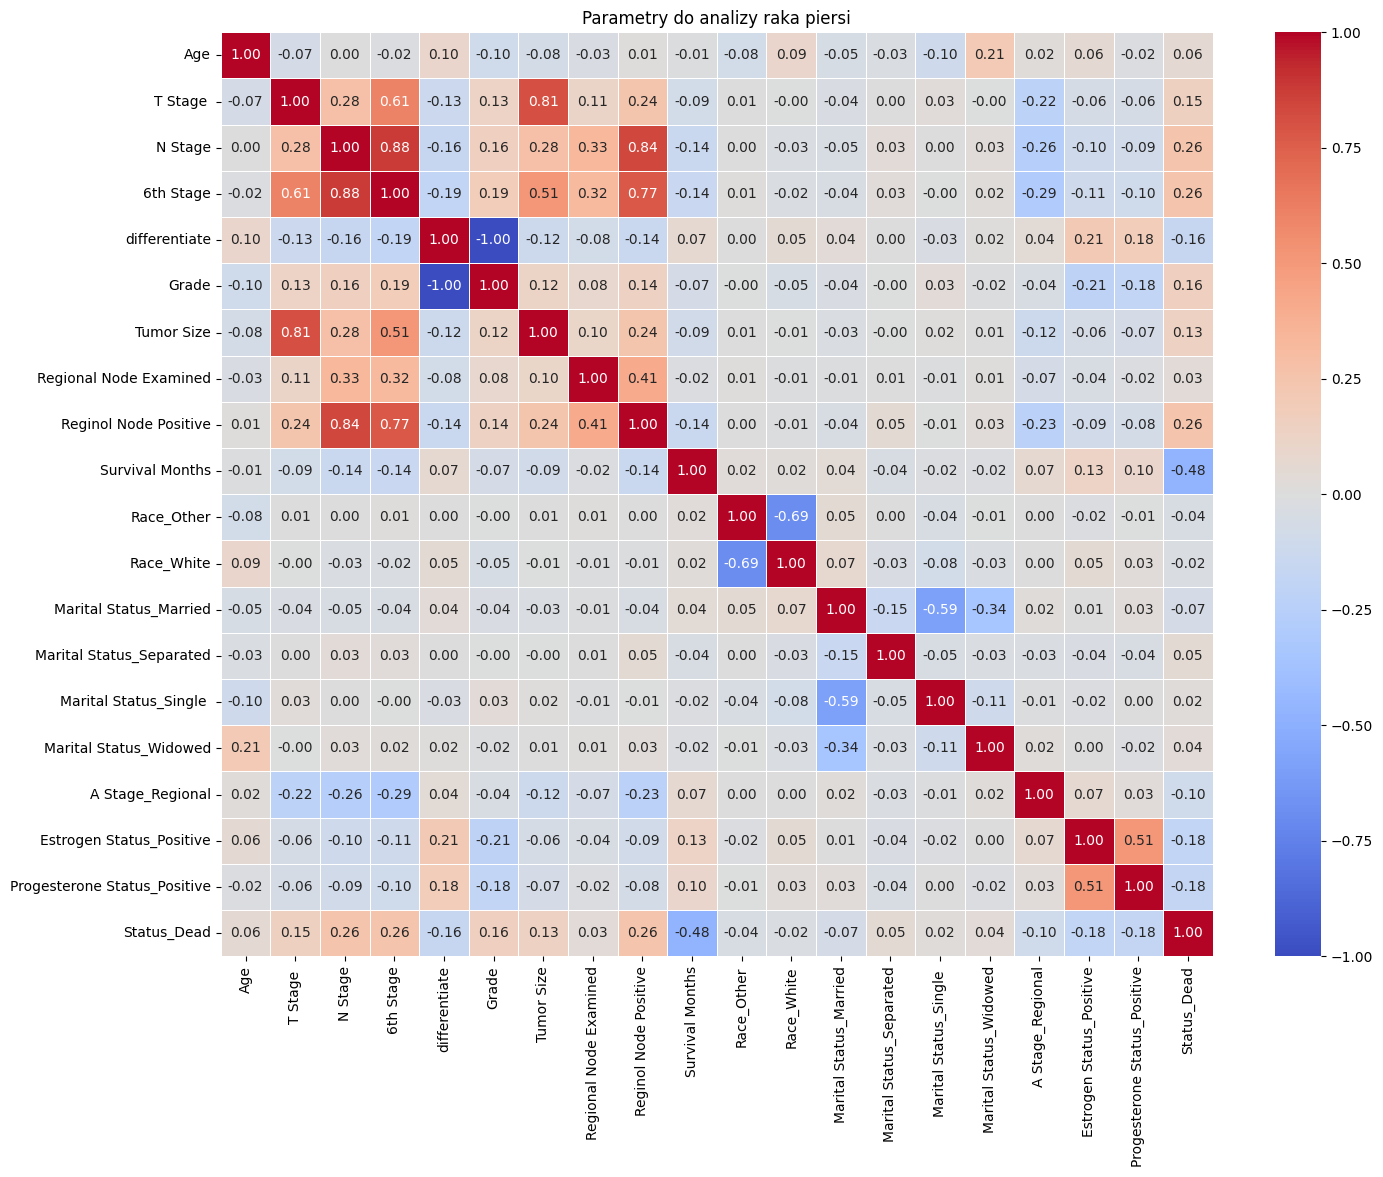

In [203]:
corr = breast_data.corr()
plt.figure(figsize=(16,12))
plt.title("Parametry do analizy raka piersi")
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=.5, cmap="coolwarm")

***Feature Selection***

Jako target wybieramy szacowana dlugosc przezywalnosci wyrazona w miesiacach. Tabela korelacji nie jest zbyt przydatna w tym wypadku poniewaz jedynym jakkolwiek mocno skorelowanym parametrem jest status_dead ktory w tym wypadku traktuje sie jako "data leak" - majac ta kolumne model juz wie czy pacjent przezyl czy nie przezyl co byloby zaburzeniem dziala algorytmu. W takiej sytuacji gdy macierz zawodzi nalezy siegnac po wiedze specjalistyczna i na jej podstawie wskazac kolumny beda czescia analizy. Skoro mowa o zmianach nowotworowych ktore odznaczaja sie w postaci guza, to wlasnie jego aspekty nalezy "sparametryzowac" i wlaczyc do analizy. 

Oto wybrane parametry:
-T Stage
-N Stage
-Age (im mlodszy pacjent tym organizm silniejszy)

Pomimo posiadania takiej zmiennej jak 6th Stage nie zostala ona wybrana do analizy ze wzgledu na wspoliniowosc z N Stage oraz T Stage, oznacza to ze 6th Stage jest suma dwoch wczesniej wspomnianych parametrow i nie przyniesie realnej korzysci dla oceny modelu.

In [204]:
y = breast_data["Survival Months"]
X = breast_data[["T Stage ", "N Stage", "Age"]]

***Data Splitting***

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

***Model Selection***

Na tym etapie nie wybiera sie jednego modelu tylko kilka ktore sa uczone i testowane w petli aby pozniej moc porownac ich wyniki i zobaczyc ktory z modelow bazowych (baseline models) jest tym najlepszym do tego datasetu

In [206]:
ridge_regressor = Ridge()
forest_regressor = RandomForestRegressor()
xgb_regressor = XGBRegressor()

models = [ridge_regressor, forest_regressor, xgb_regressor]

for model in models:
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_pred=y_pred, y_true=y_test)
    rmse = root_mean_squared_error(y_pred=y_pred, y_true=y_test)
    r2 = r2_score(y_pred=y_pred, y_true=y_test)

    model_name = model.__class__.__name__
    print(f"---Model: {model_name}---")
    print(f"Wynik bledu bezwzglednego: {mae}")
    print(f"Wynik bledu root_mean: {rmse}")
    print(f"Wynik bledu r2: {r2}")

---Model: Ridge---
Wynik bledu bezwzglednego: 18.5224829686745
Wynik bledu root_mean: 22.67055461015856
Wynik bledu r2: 0.038375092845234215
---Model: RandomForestRegressor---
Wynik bledu bezwzglednego: 19.040706661236573
Wynik bledu root_mean: 23.5449998386604
Wynik bledu r2: -0.037238903835401294
---Model: XGBRegressor---
Wynik bledu bezwzglednego: 19.120546340942383
Wynik bledu root_mean: 23.759510040283203
Wynik bledu r2: -0.056224942207336426


Wynik modeli bazowych pokazuje dosc duze zblizenie w wynikach. Zarowno MAE jak i RMSE w 3 przypadkach sa bardzo zblizone z lekka przewaga dla modelu regresji Ridge. 
Metryka R^2 pokazuje jednak ze Ridge jako jedyne jakkolwiek poprawnie przewiduje wyniki. Wartosc 0.03 jest jednak niesamowicie niska i daleko jej do zadowalajacej.

***Feature Engineering***

In [207]:
X_new = breast_data[["Age", "Tumor Size", "N Stage", "Grade", "Estrogen Status_Positive", "Progesterone Status_Positive"]]
y = breast_data["Survival Months"]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

X_train_new_scaled = scaler.fit_transform(X_train_new)
X_test_new_scaled = scaler.transform(X_test_new)

In [208]:
print("Wyniki po rozszerzeniu ilosci zmiennych.")

for model in models:

    model.fit(X_train_new_scaled, y_train_new)

    y_pred_new = model.predict(X_test_new_scaled)

    mae = mean_absolute_error(y_pred=y_pred_new, y_true=y_test_new)
    rmse = root_mean_squared_error(y_pred=y_pred_new, y_true=y_test_new)
    r2 = r2_score(y_pred=y_pred_new, y_true=y_test_new)
    
    model_name = model.__class__.__name__
    print(f"---Model: {model_name}---")
    print(f"Wynik bledu bezwzglednego: {mae}")
    print(f"Wynik bledu root_mean: {rmse}")
    print(f"Wynik bledu r2: {r2}")

Wyniki po rozszerzeniu ilosci zmiennych.
---Model: Ridge---
Wynik bledu bezwzglednego: 18.31931214543704
Wynik bledu root_mean: 22.38642799749493
Wynik bledu r2: 0.062327845622177525
---Model: RandomForestRegressor---
Wynik bledu bezwzglednego: 20.196753316473036
Wynik bledu root_mean: 25.038098528397306
Wynik bledu r2: -0.17296243071162154
---Model: XGBRegressor---
Wynik bledu bezwzglednego: 20.007099151611328
Wynik bledu root_mean: 24.954652786254883
Wynik bledu r2: -0.16515719890594482


***Model Validation***

Wynik modelu Ridge poprawil sie nieznacznie a inne modele poradzily sobie nawet gorzej. 
Tak rozbudowane struktury jak Random Forest Regressor oraz XGBRegressor najprawdopodobniej nauczyly sie danych na pamiec co skutkowalo tak slabym wynikiem, dla regresji liniowej zas dane sa zbyt skomplikowane (nieliniowe) i niemozliwym jest aby ten model zadzialal w pelni dobrze. 
Jedynym sposobem jest parametryzacja modeli (np. zablokowanie glebokosci drzewa na poziomie 3 albo 4).

In [ ]:
print(f"Wyniki po parametryzacji modeli Forest i XGBoost")

ridge_constrained = Ridge()
forest_constrained = RandomForestRegressor(max_depth=4, random_state=42)
xgb_constrained = XGBRegressor(max_depth=3, random_state=42)

models_constrained = [ridge_constrained, forest_constrained, xgb_constrained]

for model in models_constrained:
    model.fit(X_train_new_scaled, y_train_new)

    y_pred_new = model.predict(X_test_new_scaled)

    mae = mean_absolute_error(y_pred=y_pred_new, y_true=y_test_new)
    rmse = root_mean_squared_error(y_pred=y_pred_new, y_true=y_test_new)
    r2 = r2_score(y_pred=y_pred_new, y_true=y_test_new)
        
    model_name = model.__class__.__name__
    print(f"---Model: {model_name}---")
    print(f"Wynik bledu bezwzglednego: {mae}")
    print(f"Wynik bledu root_mean: {rmse}")
    print(f"Wynik bledu r2: {r2}")

Wyniki po parametryzacji modeli Forest i XGBoost
---Model: Ridge---
Wynik bledu bezwzglednego: 18.31931214543704
Wynik bledu root_mean: 22.38642799749493
Wynik bledu r2: 0.062327845622177525
---Model: RandomForestRegressor---
Wynik bledu bezwzglednego: 18.338873705342536
Wynik bledu root_mean: 22.368393357429913
Wynik bledu r2: 0.0638380256449177
---Model: XGBRegressor---
Wynik bledu bezwzglednego: 18.77332878112793
Wynik bledu root_mean: 23.18589973449707
Wynik bledu r2: -0.005840897560119629


Zmiana parametrow podzialala na bardziej rozbudowane modele, w przypadku Ridge to jest najwidoczniej jego sufit.
Aby nie sprawdzac wszystkich kombinacji parametrow recznie nalezy uzyc GirdSearch.

In [214]:
# parametryzacja XGBRegressor

xgb_params = {
    "max_depth": [2,3,4],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [50, 100, 200]
}

xgb_base = XGBRegressor(random_state = 42)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_params,
    scoring='neg_mean_absolute_error', #dazenie do zmniejszenia mae
    cv=3, #dzieli dane na 3 czesci aby przeciwdzialac przeuczeniu
    verbose=1 #pokazuje postep
)

grid_xgb.fit(X_train_new_scaled, y_train_new)

print(f"Najlepsze parametry dla {xgb_base.__class__.__name__}: {grid_xgb.best_params_}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Najlepsze parametry dla XGBRegressor: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}


In [213]:
# Random Forest Regressor

forest_params = {
    "max_depth": [2,3,4],
    "n_estimators": [50, 100, 200]
}

forest_base = RandomForestRegressor(random_state=42)

grid_forest = GridSearchCV(
    estimator=forest_base,
    param_grid=forest_params,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1
)

grid_forest.fit(X_train_new_scaled, y_train_new)

print(f"Najlepsze parametry dla {forest_base.__class__.__name__}: {grid_forest.best_params_}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Najlepsze parametry dla RandomForestRegressor: {'max_depth': 2, 'n_estimators': 100}


Po znalezieniu najlepszych parametrow dla tych dwoch modeli nalezy je od nowa wytrenowac z nowymi parametrami.

In [215]:
print(f"Wyniki po uzyciu GridSearchCV dla modeli Forest i XGBoost")

forest_constrained = RandomForestRegressor(max_depth=2,n_estimators=100 ,random_state=42)
xgb_constrained = XGBRegressor(max_depth=2, n_estimators = 50, learning_rate = 0.05, random_state=42)

models_constrained = [forest_constrained, xgb_constrained]

for model in models_constrained:
    model.fit(X_train_new_scaled, y_train_new)

    y_pred_new = model.predict(X_test_new_scaled)

    mae = mean_absolute_error(y_pred=y_pred_new, y_true=y_test_new)
    rmse = root_mean_squared_error(y_pred=y_pred_new, y_true=y_test_new)
    r2 = r2_score(y_pred=y_pred_new, y_true=y_test_new)
        
    model_name = model.__class__.__name__
    print(f"---Model: {model_name}---")
    print(f"Wynik bledu bezwzglednego: {mae}")
    print(f"Wynik bledu root_mean: {rmse}")
    print(f"Wynik bledu r2: {r2}")

Wyniki po uzyciu GridSearchCV dla modeli Forest i XGBoost
---Model: RandomForestRegressor---
Wynik bledu bezwzglednego: 18.426431226395717
Wynik bledu root_mean: 22.470480557907106
Wynik bledu r2: 0.055273419315586714
---Model: XGBRegressor---
Wynik bledu bezwzglednego: 18.454118728637695
Wynik bledu root_mean: 22.50795555114746
Wynik bledu r2: 0.052119672298431396


Wyniki obu modeli zostaly poprawione najbardziej jak tylko to bylo mozliwe. 
Pomimo tego wyniki nie sa zadowalajace i niemozliwym byloby je przedstawic w raporcie. 
Bierze sie to stad ze medycyna nie jest tak zero jedynkowa i latwa do przewidzenia, zbior danych jest zbyt ubogi aby dalo sie prognozowac ile miesiecy przezyje pacjent.
Sa dwa rozwiazania tego problemu, pierwszy to dolozenie danych (o sposobie leczenia, sposobie zycia pacjenta, genetycznych predyspozycjach, reakcji na leki itp.) co w tym przypadku jest niemozliwe poniewaz takimi danymi nie dysponuje. Drugim jest tzw. pivot czyli zmiana targetu oraz charakteru analizy. Zamiast przewidywac dlugosc zycia moznaby sklasyfikowac pacjenta jako zywego lub nie. 